In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Missing Values Observation

- Age column contains 177 missing values.
- Cabin column contains 682 missing values.
- Embarked column contains 2 missing values.
- Other columns have no missing values.

# Exploratory Data Analysis (EDA) on Titanic Dataset

## Dataset Overview

In [8]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


### Observation
More passengers died than survived in the Titanic disaster.

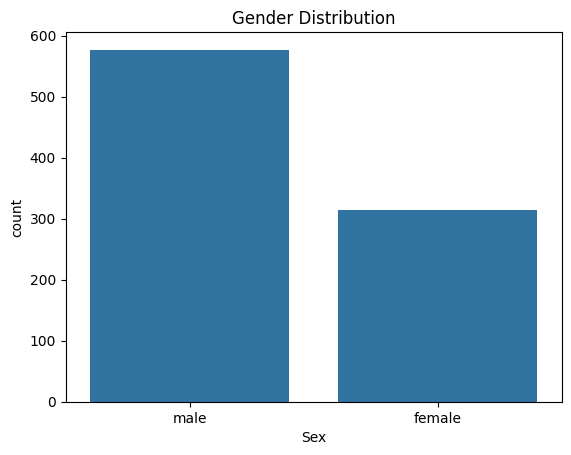

In [9]:
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

### Observation
The dataset contains more male passengers than female passengers.

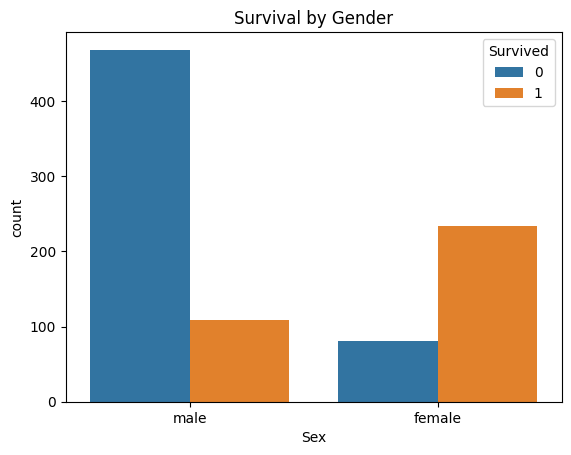

In [10]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

### Observation
Female passengers had a much higher survival rate than male passengers.

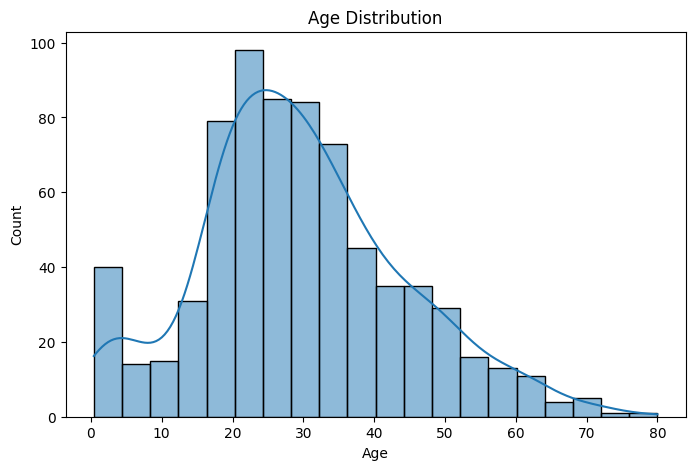

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

### Observation

Most passengers were between 20 and 40 years old.

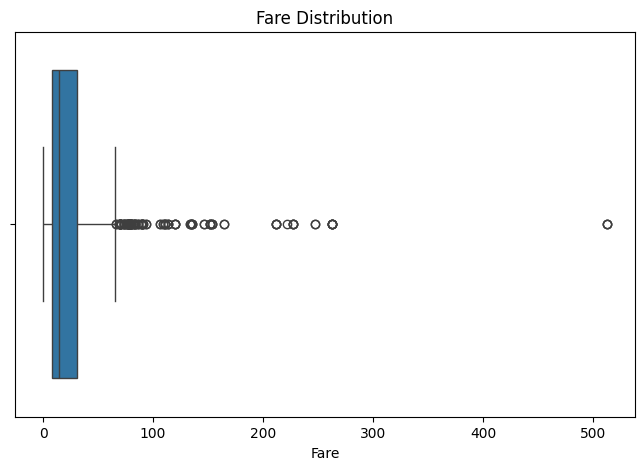

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution')
plt.show()

### Observation

The Fare column contains several outliers with very high ticket prices.

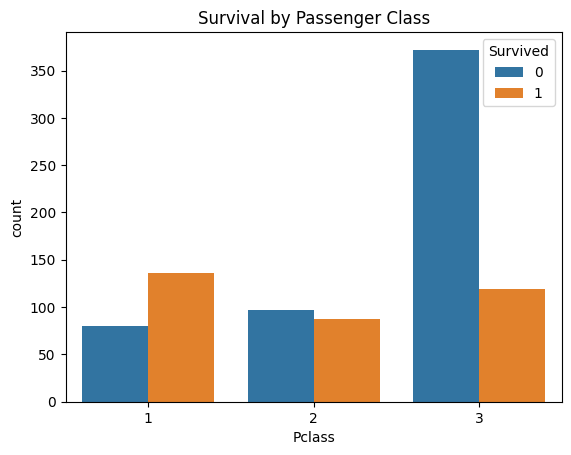

In [13]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

### Observation

First-class passengers had a higher survival rate compared to lower classes.

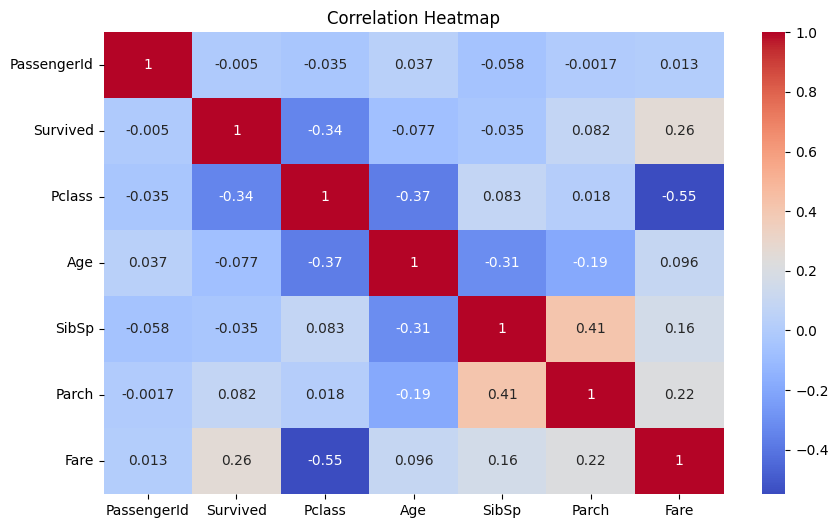

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Observation

Passenger class and fare show relationships with survival. Strong positive and negative correlations can be observed among some variables.

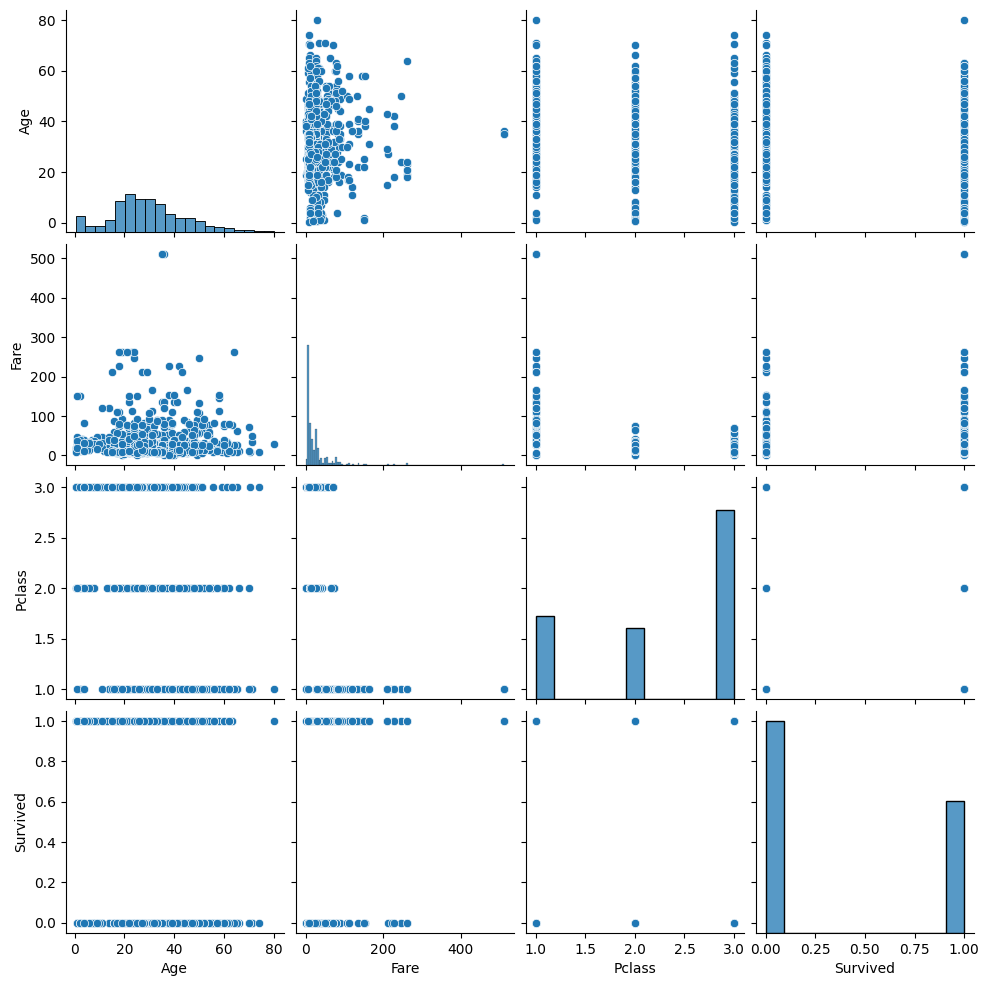

In [15]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']])
plt.show()

### Observation

The pairplot shows relationships among Age, Fare, Passenger Class, and Survival. Passengers paying higher fares generally belonged to higher classes and had better survival chances.

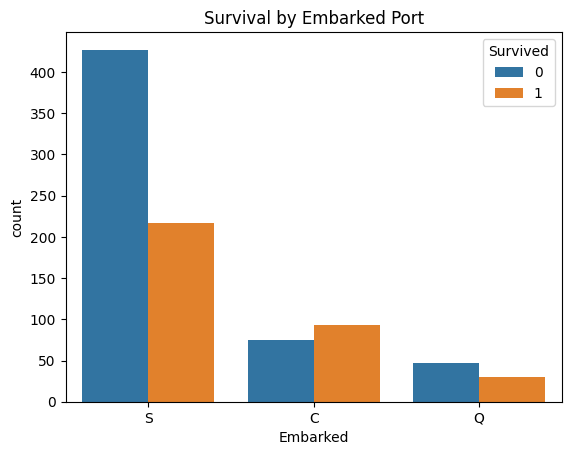

In [16]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Embarked Port')
plt.show()

### Observation

Passenger survival varied across boarding ports. Southampton had the highest number of passengers.

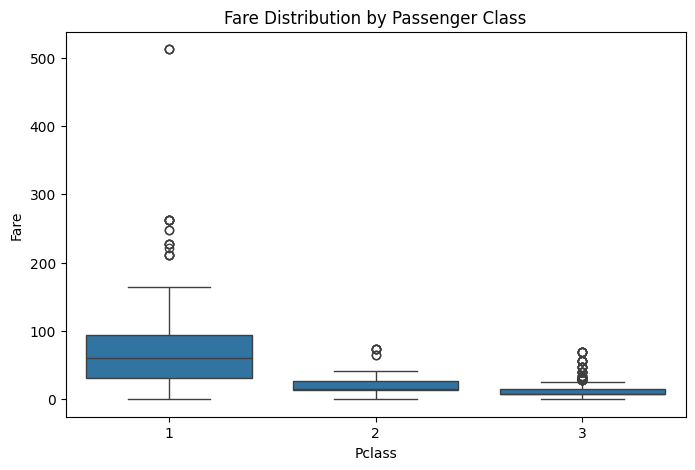

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare Distribution by Passenger Class')
plt.show()

### Observation

First-class passengers generally paid higher fares than second- and third-class passengers.

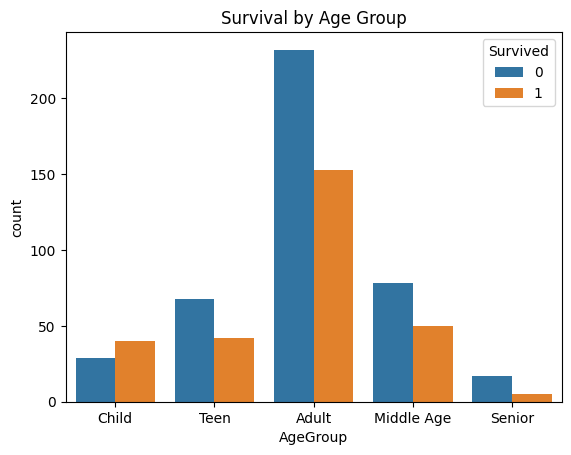

In [18]:
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,12,20,40,60,100],
                        labels=['Child','Teen','Adult','Middle Age','Senior'])

sns.countplot(x='AgeGroup', hue='Survived', data=df)
plt.title('Survival by Age Group')
plt.show()

### Observation

The majority of passengers belonged to the Adult age group. Survival rates varied across different age groups, indicating that age had an influence on survival outcomes during the Titanic disaster.


In [20]:
survival_gender = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
print(survival_gender)

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


### Observation

Female passengers had a significantly higher survival percentage than male passengers. This indicates that gender was one of the strongest factors influencing survival during the Titanic disaster.


# Final Findings

1. More passengers died than survived in the Titanic disaster.
2. Female passengers had a significantly higher survival rate than male passengers.
3. Most passengers were between 20 and 40 years old.
4. First-class passengers had better survival chances than second- and third-class passengers.
5. Fare values contained several outliers, indicating large differences in ticket prices.
6. Passenger class and fare showed noticeable relationships with survival.
7. Missing values were mainly present in the Age and Cabin columns.
8. Survival rates varied across age groups and embarkation ports.
9. Gender, passenger class, and fare were the most influential factors affecting survival.
